In [1]:
import numpy as np
import pandas as pd
import sklearn.metrics as skm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor as rfs
from sklearn.neural_network import MLPRegressor 
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression 
from mlxtend.feature_selection import SequentialFeatureSelector as sfs
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

from scipy.stats import uniform as sp_randFloat
from scipy.stats import randint as sp_randInt

def mape(Y_actual,Y_Predicted):
    mape = np.mean(np.abs((Y_actual - Y_Predicted)/Y_actual))*100
    return mape

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
dados = pd.read_csv('tab_training.csv')
dados_validation = pd.read_csv('tab_validation.csv')

dados.head(), dados_validation.head()

(   Unnamed: 0   lon   lat  year  month    prec       temp         etp
 0           1 -46.5 -23.5  1981      1  248.57  22.231935  106.048764
 1           2 -46.5 -23.5  1981      2  111.22  22.818929  101.649423
 2           3 -46.5 -23.5  1981      3  177.47  21.304839   93.651249
 3           4 -46.5 -23.5  1981      4  120.09  18.977667   67.507974
 4           5 -46.5 -23.5  1981      5   44.33  18.361613   61.594922,
    Unnamed: 0   lon   lat  year  month    prec       temp         etp
 0           1 -46.5 -23.5  2015      1  127.23  24.667742  128.816274
 1           2 -46.5 -23.5  2015      2  136.22  22.902500   98.479715
 2           3 -46.5 -23.5  2015      3  174.15  21.715806   92.170299
 3           4 -46.5 -23.5  2015      4   63.37  20.210667   71.118496
 4           5 -46.5 -23.5  2015      5   40.72  18.342903   55.356745)

In [4]:
x1 = dados[['lon','lat','year','month']]
x2 = dados[['prec','temp']]
y = dados['etp']

x1_vali= dados_validation[['lon','lat','year','month']]
x2_validation = dados_validation[['prec','temp']]
y_validation = dados_validation['etp']

In [5]:
x2 = StandardScaler().fit_transform(x2)
x2 = pd.DataFrame(x2, columns=[dados.columns[5:7]])
x2.head()

x2_validation = StandardScaler().fit_transform(x2_validation)
x2_validation = pd.DataFrame(x2_validation, columns=[dados_validation.columns[5:7]])
x2_validation.head(),x2_validation.head()

(       prec      temp
 0  0.299911  1.924636
 1  0.416020  1.210940
 2  0.905898  0.731154
 3 -0.524860  0.122619
 4 -0.817392 -0.632527,
        prec      temp
 0  0.299911  1.924636
 1  0.416020  1.210940
 2  0.905898  0.731154
 3 -0.524860  0.122619
 4 -0.817392 -0.632527)

In [6]:
x = pd.concat([x1,x2],axis=1, join='inner')
x_validation = pd.concat([x1_vali,x2_validation],axis=1, join='inner')

x.head(),x_validation.head()

(    lon   lat  year  month   (prec,)   (temp,)
 0 -46.5 -23.5  1981      1  1.070670  1.214792
 1 -46.5 -23.5  1981      2 -0.203283  1.436720
 2 -46.5 -23.5  1981      3  0.411201  0.864278
 3 -46.5 -23.5  1981      4 -0.121012 -0.015573
 4 -46.5 -23.5  1981      5 -0.823703 -0.248488,
     lon   lat  year  month   (prec,)   (temp,)
 0 -46.5 -23.5  2015      1  0.299911  1.924636
 1 -46.5 -23.5  2015      2  0.416020  1.210940
 2 -46.5 -23.5  2015      3  0.905898  0.731154
 3 -46.5 -23.5  2015      4 -0.524860  0.122619
 4 -46.5 -23.5  2015      5 -0.817392 -0.632527)

In [ ]:
r2_trainValues_rf=[]
rmse_trainValues_rf = []
mape_trainValues_rf = []
rrmse_trainValues_rf = []

r2_testValues_rf=[]
rmse_testValues_rf = []
mape_testValues_rf = []
rrmse_testValues_rf = []

n_times=100
 
## Performing bootstrapping
for i in range(n_times):
    
    
    #Split the data into training and testing set
    
    # Chaning the seed value for each iteration
    x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=.3, random_state=41+i)
 
    rf_modelo = rfs().fit(x_treino, y_treino)
    hyperpar_space_rf = {'max_depth':[1,3,5,7,9],
                  'n_estimators':[50,100,150,200,250,500,750,1000],
                  'max_features':[1,2,4,6,8]
                 }
    
    rs_rf = RandomizedSearchCV(rf_modelo, param_distributions=hyperpar_space_rf,
                        n_iter=30, scoring="r2", random_state=41+i,
                        n_jobs=-1, cv=10, return_train_score=True).fit(x_treino,y_treino)
    
    ## training results
    yest_treino = rs_rf.best_estimator_.predict(x_treino)
    
    r2_train_rf=skm.r2_score(y_treino,yest_treino)
    rmse_train_rf = skm.mean_squared_error(y_treino,yest_treino)**0.5
    mape_train_rf = mape(y_treino,yest_treino)
    rrmse_train_rf = rmse_train_rf*100/np.mean(y_treino)
    
    pd.DataFrame.from_dict(rs_rf.cv_results_).to_csv('rf_iter/random_forest_'+str(i)+'_iter.csv')
    importancia = rs_rf.best_estimator_.feature_importances_
    importancia_graf = pd.DataFrame({'lon':[importancia[0]],'lat':[importancia[1]],
                                     'year':[importancia[2]],'month':[importancia[3]],
                                     'prec':[importancia[4]], 'temp':[importancia[5]]
                                })
    pd.DataFrame.from_dict(importancia_graf).to_csv('rf_iter/random_forest_'+str(i)+'_importance.csv')
    
    # Storing train accuracy values
    r2_trainValues_rf.append(r2_train_rf)
    rmse_trainValues_rf.append(rmse_train_rf)
    mape_trainValues_rf.append(mape_train_rf)
    rrmse_trainValues_rf.append(rrmse_train_rf)

    ### test set
    yest_teste = rs_rf.best_estimator_.predict(x_teste)
    
    ### testing results
    
    r2_test_rf= skm.r2_score(y_teste,yest_teste)
    rmse_test_rf = skm.mean_squared_error(y_teste,yest_teste)**0.5
    mape_test_rf = mape(y_teste,yest_teste)
    rrmse_test_rf = rmse_test_rf*100/np.mean(y_teste)
    
    # Storing test accuracy values
    r2_testValues_rf.append(r2_test_rf)
    rmse_testValues_rf.append(rmse_test_rf)
    mape_testValues_rf.append(mape_test_rf)
    rrmse_testValues_rf.append(rrmse_test_rf)
    
    
################################################
# Final accuracy
print('Final average train score',np.mean(r2_trainValues_rf))
print('Final average train rmse',np.mean(rmse_trainValues_rf))
print('Final average train mape',np.mean(mape_trainValues_rf))

print('Final average test score',np.mean(r2_testValues_rf))
print('Final average test rmse',np.mean(rmse_testValues_rf))
print('Final average test mape',np.mean(mape_testValues_rf))

<AxesSubplot:xlabel='iter'>

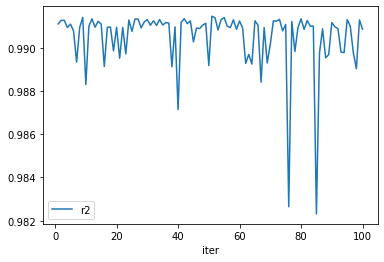

In [8]:
train_results = pd.DataFrame(
    {'r2':r2_trainValues_rf,
    'rmse':rmse_trainValues_rf,
    'mape':mape_trainValues_rf,
    'rrmse':rrmse_trainValues_rf, 
    'iter':np.arange(1,n_times+1)}
)

train_results.plot('iter','r2')

<AxesSubplot:xlabel='iter'>

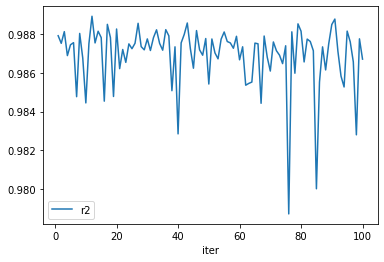

In [9]:
test_results = pd.DataFrame(
    {'r2':r2_testValues_rf,
    'rmse':rmse_testValues_rf,
    'mape':mape_testValues_rf,
    'rrmse':rrmse_testValues_rf, 
    'iter':np.arange(1,n_times+1)}
)

test_results.plot('iter','r2')

In [10]:
test_results.to_csv('rf_iter/random_forest_teste_metrics.csv')
train_results.to_csv('rf_iter/random_forest_train_metrics.csv')

In [7]:
r2_trainValues_mlp=[]
rmse_trainValues_mlp = []
mape_trainValues_mlp = []
rrmse_trainValues_mlp = []

r2_testValues_mlp=[]
rmse_testValues_mlp = []
mape_testValues_mlp = []
rrmse_testValues_mlp = []

n_times=100
 
## Performing bootstrapping
for i in range(n_times):
    
    
    #Split the data into training and testing set
    
    # Chaning the seed value for each iteration
    x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=.3, random_state=41+i)
 
    ann_modelo= MLPRegressor().fit(x_treino,y_treino)
    hyperpar_space_mlp = {'hidden_layer_sizes':[(5,5),(10,10),(10,5,10),(10,10,10)],
                          'activation':['logistic','tanh','identity'],
                          'max_iter':[50,100,150,200,250,500,750,1000],
                          'learning_rate_init': [0.001, 0.01,0.05, 0.1, 0.2, 0.3],
                          'solver':['adam','sgd','lbfgs'],
                          'learning_rate':['constant', 'invscaling', 'adaptive'],
                          'alpha':[0.001, 0.01,0.05, 0.1, 0.2, 0.3]
                         }
    
    rs_mlp = RandomizedSearchCV(ann_modelo, param_distributions=hyperpar_space_mlp,
                        n_iter=30, scoring="r2", random_state=41+i,
                        n_jobs=-1, cv=10, return_train_score=True).fit(x_treino,y_treino)
    pd.DataFrame.from_dict(rs_mlp.cv_results_).to_csv('mlp_iter/mlp_'+str(i)+'_iter.csv')
    
    ## training results
    yest_treino = rs_mlp.best_estimator_.predict(x_treino)
    
    r2_train_mlp= skm.r2_score(y_treino,yest_treino)
    rmse_train_mlp = skm.mean_squared_error(y_treino,yest_treino)**0.5
    mape_train_mlp = mape(y_treino,yest_treino)
    rrmse_train_mlp = rmse_train_mlp*100/np.mean(y_treino)
    
   
    # Storing train accuracy values
    r2_trainValues_mlp.append(r2_train_mlp)
    rmse_trainValues_mlp.append(rmse_train_mlp)
    mape_trainValues_mlp.append(mape_train_mlp)
    rrmse_trainValues_mlp.append(rrmse_train_mlp)

    ### test set
    yest_teste = rs_mlp.best_estimator_.predict(x_teste)
    
    ### testing results
    
    r2_test_mlp= skm.r2_score(y_teste,yest_teste)
    rmse_test_mlp = skm.mean_squared_error(y_teste,yest_teste)**0.5
    mape_test_mlp = mape(y_teste,yest_teste)
    rrmse_test_mlp = rmse_test_mlp*100/np.mean(y_teste)
    
    # Storing test accuracy values
    r2_testValues_mlp.append(r2_test_mlp)
    rmse_testValues_mlp.append(rmse_test_mlp)
    mape_testValues_mlp.append(mape_test_mlp)
    rrmse_testValues_mlp.append(rrmse_test_mlp)
    
################################################

# Final accuracy
print('Final average train score',np.mean(r2_trainValues_mlp))
print('Final average train rmse',np.mean(rmse_trainValues_mlp))
print('Final average train mape',np.mean(mape_trainValues_mlp))

print('Final average test score',np.mean(r2_testValues_mlp))
print('Final average test rmse',np.mean(rmse_testValues_mlp))
print('Final average test mape',np.mean(mape_testValues_mlp))

Final average train score 0.9476592976624681
Final average train rmse 5.272553861348806
Final average train mape 6.294536980705939
Final average test score 0.9477074998613252
Final average test rmse 5.265487010531699
Final average test mape 6.2973128475079445


<AxesSubplot:xlabel='iter'>

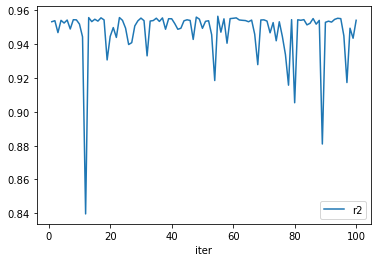

In [8]:
train_results_mlp = pd.DataFrame(
    {'r2':r2_trainValues_mlp,
    'rmse':rmse_trainValues_mlp,
    'mape':mape_trainValues_mlp,
    'rrmse':rrmse_trainValues_mlp,
    'iter':np.arange(1,n_times+1)}
)

train_results_mlp.plot('iter','r2')

<AxesSubplot:xlabel='iter'>

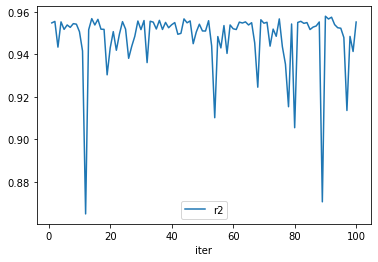

In [9]:
test_results_mlp = pd.DataFrame(
    {'r2':r2_testValues_mlp,
    'rmse':rmse_testValues_mlp,
    'mape':mape_testValues_mlp,
    'rrmse':rrmse_testValues_mlp,
    'iter':np.arange(1,n_times+1)}
)

test_results_mlp.plot('iter','r2')

In [10]:
test_results_mlp.to_csv('mlp_iter/mlp_teste_metrics.csv')
train_results_mlp.to_csv('mlp_iter/mlp_train_metrics.csv')

In [7]:
r2_trainValues_sw=[]
rmse_trainValues_sw = []
mape_trainValues_sw = []
rrmse_trainValues_sw = []

r2_testValues_sw=[]
rmse_testValues_sw = []
mape_testValues_sw = []
rrmse_testValues_sw = []

n_times=100
 
## Performing bootstrapping
for i in range(n_times):
    
    
    #Split the data into training and testing set
    
    # Chaning the seed value for each iteration
    x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=.3, random_state=41+i)
 
    #####
    sw_modelo = LinearRegression()
    sfs_modelo = sfs(sw_modelo,k_features=6, forward=True, scoring='r2',cv=10)
    sfs_modelo=sfs_modelo.fit(x_treino, y_treino)
    
    pd.DataFrame.from_dict(sfs_modelo.get_metric_dict()).T.to_csv('sw_iter/sw_'+str(i)+'_iter.csv')
    tabela = pd.DataFrame.from_dict(sfs_modelo.get_metric_dict()).T
    tabela=tabela.sort_values('avg_score', ascending=False)['feature_names'].head(1)
    tabela = tabela.tolist()
        
    xobs_treino = x_treino[list(tabela[0][0:])]
    xobs_treino = sm.add_constant(xobs_treino)
    
    resultado = sm.OLS(y_treino,xobs_treino).fit()
    
    ## training results
    yest_treino = resultado.fittedvalues
    
    
    r2_train_sw=skm.r2_score(y_treino,yest_treino)
    rmse_train_sw = skm.mean_squared_error(y_treino,yest_treino)**0.5
    mape_train_sw = mape(y_treino,yest_treino)
    rrmse_train_sw = rmse_train_sw*100/np.mean(y_treino)
    
    
    
    # Storing train accuracy values
    r2_trainValues_sw.append(r2_train_sw)
    rmse_trainValues_sw.append(rmse_train_sw)
    mape_trainValues_sw.append(mape_train_sw)
    rrmse_trainValues_sw.append(rrmse_train_sw)

    ### test set
    xobs_teste = x_teste[list(tabela[0][0:])]
    xobs_teste = sm.add_constant(xobs_teste)
    yest_teste = resultado.predict(xobs_teste)
    
    ### testing results
    
    r2_test_sw= skm.r2_score(y_teste,yest_teste)
    rmse_test_sw = skm.mean_squared_error(y_teste,yest_teste)**0.5
    mape_test_sw = mape(y_teste,yest_teste)
    rrmse_test_sw = rmse_test_sw*100/np.mean(y_teste)
    
    # Storing test accuracy values
    r2_testValues_sw.append(r2_test_sw)
    rmse_testValues_sw.append(rmse_test_sw)
    mape_testValues_sw.append(mape_test_sw)
    rrmse_testValues_sw.append(rrmse_test_sw)
    
    
################################################
# Final accuracy
print('Final average train score',np.mean(r2_trainValues_sw))
print('Final average train rmse',np.mean(rmse_trainValues_sw))
print('Final average train mape',np.mean(mape_trainValues_sw))

print('Final average test score',np.mean(r2_testValues_sw))
print('Final average test rmse',np.mean(rmse_testValues_sw))
print('Final average test mape',np.mean(mape_testValues_sw))

Final average train score 0.9596297947046379
Final average train rmse 4.666182482244073
Final average train mape 5.600706064597342
Final average test score 0.9596586894850738
Final average test rmse 4.658474570354686
Final average test mape 5.590061965384589


<AxesSubplot:xlabel='iter'>

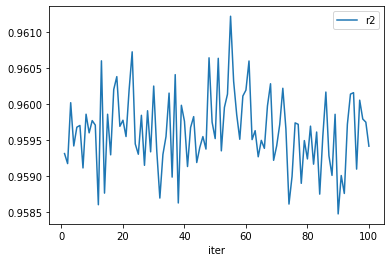

In [8]:
train_results_sw = pd.DataFrame(
    {'r2':r2_trainValues_sw,
    'rmse':rmse_trainValues_sw,
    'mape':mape_trainValues_sw,
    'rrmse':rrmse_trainValues_sw,
    'iter':np.arange(1,n_times+1)}
)

train_results_sw.plot('iter','r2')

<AxesSubplot:xlabel='iter'>

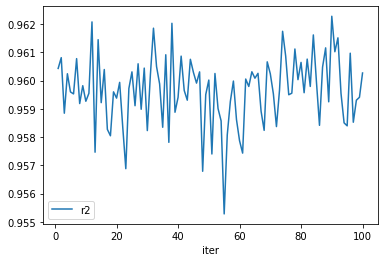

In [9]:
test_results_sw = pd.DataFrame(
    {'r2':r2_testValues_sw,
    'rmse':rmse_testValues_sw,
    'mape':mape_testValues_sw,
    'rrmse':rrmse_testValues_sw,
    'iter':np.arange(1,n_times+1)}
)

test_results_sw.plot('iter','r2')

In [10]:
test_results_sw.to_csv('sw_iter/sw_teste_metrics.csv')
train_results_sw.to_csv('sw_iter/sw_train_metrics.csv')